# Linear Regression from Scratch

In this notebook, we build **Linear Regression** step by step using only NumPy,
and train it using **Gradient Descent**. We also compare it with
scikit-learn's built-in Linear Regression to check that our version works correctly.

By the end of this notebook, you will understand:
- What Linear Regression is and why we use it
- How the math behind it works (in two different ways)
- How to implement it in Python
- How to check if the model is doing a good job

## 1 What is Linear Regression?

Linear Regression is a foundational machine learning algorithm used to predict continuous numerical values (like price, age, or temperature) rather than discrete categories.

**Everyday Analogy:**
Suppose you want to estimate a house's market price based on its square footage. If you chart square footage on the X-axis and price on the Y-axis, a general upward trend emerges: larger homes generally command higher prices. Linear Regression identifies the optimal straight line fitting this spatial distribution.

Once established, this trendline allows you to estimate the value of any unlisted property simply by plugging in its square footage.

The relationship is represented by a classic linear equation:

$$y = wx + b$$

* **$y$ (Target):** The unknown value you want to predict (e.g., house price).
* **$x$ (Feature):** The known input variable (e.g., house size in sq ft).
* **$w$ (Weight):** The line's slope, measuring how much $y$ changes for every unit increase in $x$.
* **$b$ (Bias):** The y-intercept, representing the baseline value of $y$ when $x = 0$.

## 2. Why do we use Linear Regression?

We use Linear Regression when:
- We want to predict a **continuous number** (like price, temperature, salary),
  not a category (like "yes/no" or "cat/dog")
- We believe there is a **straight-line relationship** between the input(s)
  and the output. For example, more study hours usually means a higher exam score.
- We want a model that is **simple, fast, and easy to explain** to others.
  Unlike some complex models, we can clearly see how much each input affects
  the final prediction.

**When NOT to use it:**
- If the relationship between input and output is not a straight line
  (for example, a curve), plain Linear Regression will not fit well.
- If the output is a category instead of a number (use Logistic Regression instead).

## 3 What Kind of Data Does Linear Regression Need?

To build a reliable linear model, your dataset needs specific characteristics:

* **Input Features ($X$):** One or more numerical values that describe your data points (e.g., house size, room count, building age).
* **Target Variable ($y$):** A single continuous numerical value you want to predict (e.g., total price).
* **Linearity:** The relationship between your inputs and output should follow a roughly straight-line trend. If the pattern is heavily curved, standard linear regression won't fit well without transformation.
* **Feature Scaling:** When working with multiple inputs measured in vastly different units (e.g., square feet vs. bedroom count), scaling keeps larger numbers from overwhelming the optimization process. 

*(Note: Because this introductory notebook uses only a single feature, feature scaling isn't required here, but it's essential for multi-feature models.)*

### Environment Setup & Dependencies

Before we start building our model, we bring in a few standard Python tools to help with math, drawing graphs, and checking our accuracy:

* **`numpy` (`np`):** The main math library in Python. It helps us work with lists of numbers and run calculations instantly without slow loops.
* **`matplotlib.pyplot` (`plt`):** The graphing library. We use this to plot our data points on a chart and draw our prediction line.
* **`SklearnLinearRegression`:** A ready-to-use linear regression model built by professionals. We import it as a benchmark to make sure our custom code gets the exact same answers.
* **`mean_squared_error` & `r2_score`:** Two quick ways to grade how well our model performs:
  * **MSE (Mean Squared Error):** Measures the average mistake size. Lower numbers mean better accuracy.
  * **R² Score:** Measures how much of the pattern our line captures (a score of 1.0 means a perfect fit).
* **`BaseModel`:** A starting template from our project folder that gives our custom model its basic structure (like standard `fit` and `predict` commands).
* **`np.random.seed(42)`:** Freezes Python's random number generator. This guarantees that any random numbers created in this notebook stay the exact same every single time you click "Run."

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from ml_from_scratch.base_model import BaseModel

np.random.seed(42)

## 4. The Math Behind Linear Regression — Method 1: Gradient Descent

### Step 1: The Basic Formula

For a single input, we calculate our prediction using this simple formula:

$$\hat{y} = w x + b$$

* **$\hat{y}$ ("y-hat"):** The output value our model predicts.
* **$x$:** The input value we give to the model.
* **$w$ (Weight):** The number that controls the slope of the line.
* **$b$ (Bias):** The starting point where the line meets the vertical axis.

---

### Step 2: Measuring the Error

To check how accurate the predictions are, we calculate the **Mean Squared Error (MSE)**:

$$\text{Cost} = \frac{1}{n} \sum (\hat{y} - y)^2$$

We square the difference between our guess ($\hat{y}$) and the real value ($y$) because:
1. It keeps positive and negative errors from cancelling each other out.
2. It makes large mistakes count much more than small ones.

Our goal is to change $w$ and $b$ to make this total cost as small as possible.

---

### Step 3: Finding the Right Direction

Gradient Descent finds the fastest path to reduce the cost by taking small steps downward.

We use **derivatives** to measure how much the cost changes when we adjust $w$ or $b$:

* **Change in cost for $w$:** $\frac{\partial \text{Cost}}{\partial w} = \frac{2}{n} \sum (\hat{y} - y) \cdot x$
* **Change in cost for $b$:** $\frac{\partial \text{Cost}}{\partial b} = \frac{2}{n} \sum (\hat{y} - y)$

---

### Step 4: Updating $w$ and $b$

After calculating the direction, we adjust both numbers:

$$w = w - (\text{learning\_rate} \cdot \frac{\partial \text{Cost}}{\partial w})$$
$$b = b - (\text{learning\_rate} \cdot \frac{\partial \text{Cost}}{\partial b})$$

* **learning_rate:** Controls the size of each step.
  * **Too high:** The model might jump past the lowest point.
  * **Too low:** Training will take a very long time.

We repeat this loop—**predict, check error, update values**—until the cost stops going down.

## 5. Method 2: The Normal Equation

Instead of using Gradient Descent to adjust values step by step, we can calculate the best parameters instantly using linear algebra.

---

### The Direct Formula

By combining all inputs into a matrix $X$ and all actual outputs into a vector $y$, we can find the exact best weights ($W$) in a single step:

$$W = (X^T X)^{-1} X^T y$$

Here is what each term means:

* **$X$:** Matrix of all input features, with a column of $1\text{s}$ added so the formula automatically calculates the bias ($b$).
* **$X^T$:** Transpose of matrix $X$ (rows and columns swapped).
* **$(X^T X)^{-1}$:** Matrix inverse of $(X^T X)$.
* **$W$:** A single vector containing both the optimal weights ($w$) and bias ($b$).

---

### Comparison: Normal Equation vs. Gradient Descent

| Feature | Normal Equation | Gradient Descent |
| :--- | :--- | :--- |
| **Speed** | Instant on small datasets | Requires thousands of update steps |
| **Parameters** | No learning rate needed | Requires setting a learning rate |
| **Scalability** | Gets extremely slow on very large datasets | Handles millions of data points easily |
| **Exactness** | Computes the exact mathematical solution | Finds a close approximation |

---

### Why We Focus on Gradient Descent

While the Normal Equation works well for smaller datasets, inverting large matrices requires significant memory and computing power. 

Gradient Descent scales much better to massive datasets and forms the core optimization method used across modern machine learning and deep learning models (such as Neural Networks).

## 6. Creating a Synthetic Dataset

To see how Linear Regression works, we will build a simple dummy dataset instead of loading an external file. Creating our own data gives us total control and allows us to test if our model recovers the exact numbers we started with.

We will generate data points based on this underlying equation:

$$y = 4 + 3x$$

* **True Bias ($b$):** $4$
* **True Weight ($w$):** $3$

To make the dataset realistic, we will add a small amount of random noise to each point, mimicking the randomness found in real-world measurements.

In [2]:
# Number of data points we want to create
n_samples = 100

# Generate random input values (X) between 0 and 2
X = 2 * np.random.rand(n_samples, 1)

# Generate output values (y) using the formula y = 4 + 3x, plus some random noise
noise = np.random.randn(n_samples, 1)
y = 4 + 3 * X + noise

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X[:5])
print("First 5 rows of y:\n", y[:5])

Shape of X: (100, 1)
Shape of y: (100, 1)
First 5 rows of X:
 [[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]]
First 5 rows of y:
 [[6.33428778]
 [9.40527849]
 [8.48372443]
 [5.60438199]
 [4.71643995]]


## 7. Visualizing the Data

Before training any model, it's always a good habit to **look at the data**
first. This helps us confirm whether a straight line actually makes sense
for this data.

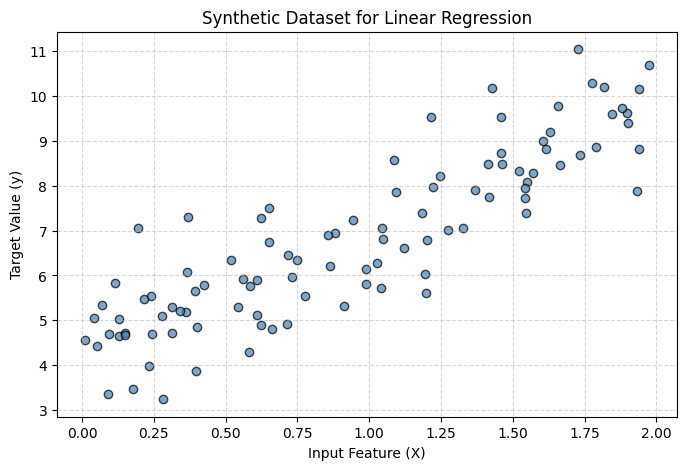

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", alpha=0.7, edgecolor="k")
plt.xlabel("Input Feature (X)")
plt.ylabel("Target Value (y)")
plt.title("Synthetic Dataset for Linear Regression")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 8. Implementing Linear Regression from Scratch

Now we implement our own `LinearRegression` class. It follows the same
`.fit()` and `.predict()` pattern as scikit-learn, and it inherits from
our shared `BaseModel` class.

In [4]:
class LinearRegression(BaseModel):
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        super().__init__()
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        # Get number of rows (samples) and columns (features)
        n_samples = len(X)
        n_features = X.shape[1]

        # Initialize weights with zeros
        self.weights = np.zeros((n_features, 1))
        self.bias = 0.0

        # Reshape y to make sure it's a column vector
        y = y.reshape(-1, 1)

        # Training loop
        for i in range(self.n_iterations):
            # 1. Predict y values using y = w*x + b
            y_pred = np.dot(X, self.weights) + self.bias

            # 2. Find difference between predictions and real values
            error = y_pred - y

            # 3. Calculate mean squared error (cost)
            cost = np.mean(error ** 2)
            self.cost_history.append(cost)

            # 4. Calculate gradients (derivatives)
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            # 5. Update weights and bias
            self.weights = self.weights - (self.learning_rate * dw)
            self.bias = self.bias - (self.learning_rate * db)

        self.is_fitted = True
        return self

    def predict(self, X):
        self._check_is_fitted()
        # Calculate final prediction: y = w*x + b
        y_pred = np.dot(X, self.weights) + self.bias
        return y_pred

In [5]:
model = LinearRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X, y)

print("Learned weight:", model.weights[0][0])
print("Learned bias:", model.bias)

Learned weight: 2.7701133864384917
Learned bias: 4.215096157546739


## 9. Checking if the Model Actually Learned (Convergence Plot)

While training, we saved the cost at every iteration inside `cost_history`.
Plotting this shows us whether the model's error was going down over time,
which tells us that Gradient Descent was working correctly.

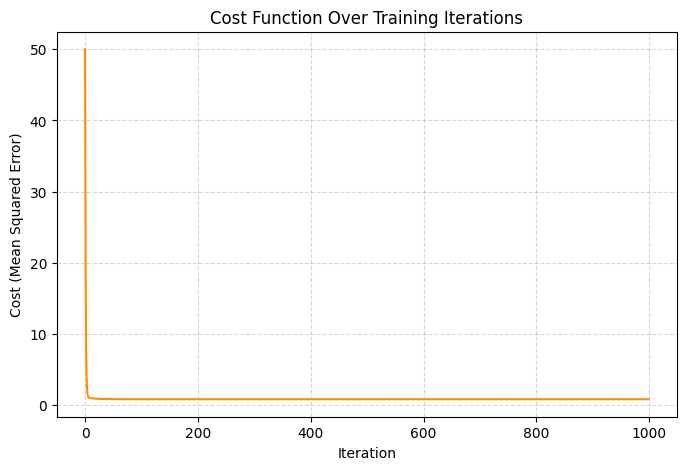

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(model.cost_history)), model.cost_history, color="darkorange")
plt.xlabel("Iteration")
plt.ylabel("Cost (Mean Squared Error)")
plt.title("Cost Function Over Training Iterations")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 10. Visualizing the Fitted Line

Now let's draw our learned line on top of the original data points, to see
how well it fits.

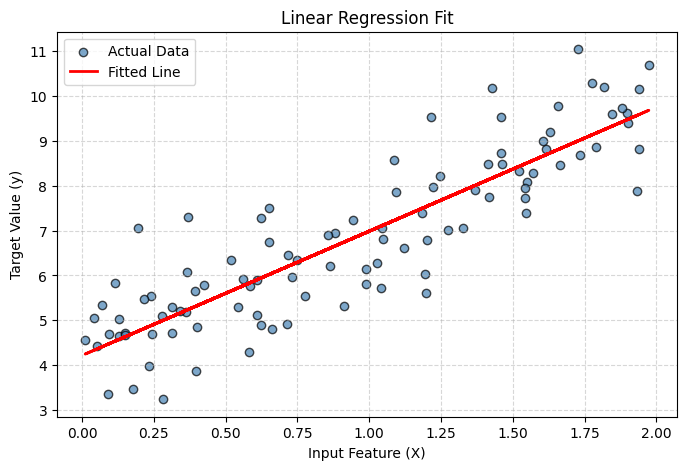

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", alpha=0.7, edgecolor="k", label="Actual Data")
plt.plot(X, model.predict(X), color="red", linewidth=2, label="Fitted Line")
plt.xlabel("Input Feature (X)")
plt.ylabel("Target Value (y)")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 11. How Do We Measure Model Accuracy?

For regression problems (predicting numbers), we usually don't use
"accuracy" the way we do for classification. Instead, we use these metrics:

**Mean Squared Error (MSE)**
The average of the squared differences between predictions and actual
values. Lower is better. Squaring means big mistakes are punished more.

**Root Mean Squared Error (RMSE)**
Just the square root of MSE. This brings the error back to the same unit
as our original target value, making it easier to interpret. For example,
if we are predicting house prices in lakhs, RMSE tells us roughly how many
lakhs off our predictions are, on average.

**R² Score (R-squared)**
Tells us what percentage of the pattern in the data our model was able to
explain. It ranges from 0 to 1 (sometimes negative for very bad models):
- R² = 1 means a perfect fit
- R² = 0 means the model is no better than just predicting the average value every time
- Closer to 1 is better

In [8]:
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.8066
Root Mean Squared Error (RMSE): 0.8981
R² Score: 0.7693


## 12. Comparing With Scikit-learn

Let's train scikit-learn's official `LinearRegression` model on the exact
same data, and compare its results with our own implementation. If our
model is correct, both should give very similar weight, bias, and error values.

In [9]:
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X, y)

sklearn_pred = sklearn_model.predict(X)
sklearn_mse = mean_squared_error(y, sklearn_pred)
sklearn_r2 = r2_score(y, sklearn_pred)

print("Scikit-learn weight:", sklearn_model.coef_[0][0])
print("Scikit-learn bias:", sklearn_model.intercept_[0])
print(f"Scikit-learn MSE: {sklearn_mse:.4f}")
print(f"Scikit-learn R² Score: {sklearn_r2:.4f}")

Scikit-learn weight: 2.7701133864384837
Scikit-learn bias: 4.215096157546747
Scikit-learn MSE: 0.8066
Scikit-learn R² Score: 0.7693


In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Weight", "Bias", "MSE", "R² Score"],
    "Our Model": [model.weights[0][0], model.bias, mse, r2],
    "Scikit-learn": [sklearn_model.coef_[0][0], sklearn_model.intercept_[0], sklearn_mse, sklearn_r2]
})

comparison

,Metric,Our Model,Scikit-learn
0,Weight,2.770113,2.770113
1,Bias,4.215096,4.215096
2,MSE,0.806585,0.806585
3,R² Score,0.769274,0.769274


## 13. Conclusion

**What We Covered:**
* **The Fundamentals:** Explored what Linear Regression is and when to apply it.
* **The Math:** Looked under the hood using both Gradient Descent and the Normal Equation.
* **Building from Scratch:** Coded our own working model using standard NumPy.
* **Visualization:** Plotted the training process and visually evaluated the line of best fit.
* **Evaluation:** Measured accuracy using standard metrics like MSE, RMSE, and $R^2$ Score.
* **Validation:** Verified our model against `scikit-learn` to ensure accurate predictions.

**Key Takeaway:**  
Our custom implementation closely matches `scikit-learn`'s results, proving that the underlying mechanics work as expected!

## A Note on How This Notebook Was Built

I used AI tools along with other learning resources articles,
documentation, and course material to help me understand this
algorithm and structure this notebook professionally.